In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
users=pd.read_csv("cleaned_users_dataset.csv")
api=pd.read_csv("cleaned_api_dataset.csv")
api_usage=pd.read_csv("cleaned_api_usage.csv")
api_logs=pd.read_csv("cleaned_api_logs.csv")

In [7]:
api.shape
users.shape
api_usage.shape
api_logs.shape

(5000, 14)

In [16]:
# users.info()
# api.info()
api_usage.info()
api_logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 4710 entries, 0 to 4709
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   usage_id             4710 non-null   int64  
 1   user_id              4710 non-null   int64  
 2   api_id               4710 non-null   int64  
 3   usage_date           4710 non-null   str    
 4   total_requests       4710 non-null   int64  
 5   successful_requests  4710 non-null   int64  
 6   failed_requests      4710 non-null   int64  
 7   success_rate         4710 non-null   float64
 8   error_rate           4710 non-null   float64
dtypes: float64(2), int64(6), str(1)
memory usage: 331.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   log_id                5000 non-null   int64  
 1   api_id                5000 non-null   int

In [18]:
users['signup_date']=pd.to_datetime(users['signup_date'])
users.info()

api_usage['usage_date']=pd.to_datetime(api_usage['usage_date'])
api_usage.info()

api_logs['request_time']=pd.to_datetime(api_logs['request_time'])
api_logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            5000 non-null   int64         
 1   username           5000 non-null   str           
 2   company_name       5000 non-null   str           
 3   subscription_type  5000 non-null   str           
 4   country            5000 non-null   str           
 5   signup_date        5000 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 234.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 4710 entries, 0 to 4709
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   usage_id             4710 non-null   int64         
 1   user_id              4710 non-null   int64         
 2   api_id               4710 non-null   int64         
 3   usage_date   

In [19]:
df=api_usage.merge(users,on='user_id',how='left')\
  .merge(api,on='api_id',how='left')

In [31]:
total_requests=api_usage['total_requests'].sum()
print(f'total_requests:-',total_requests)

success_rate=round((api_usage['successful_requests'].sum() / total_requests)*100,2)
print('\nsuccess_rate:-',success_rate)

error_rate=round((api_usage['failed_requests'].sum()/total_requests)*100,2)
print('\nerror_rate:-',error_rate)

top_apis = df.groupby('api_name')['total_requests'].sum().sort_values(ascending=False).head(10)
print('\ntop_apis:-',top_apis)

category_usage=df.groupby('api_category')['total_requests'].sum().sort_values(ascending=False)
print('\ncategory_usage:-',category_usage)

total_requests:- 3025583735

success_rate:- 98.0

error_rate:- 2.0

top_apis:- api_name
Twilio SMS Gateway API            149865385
FedEx Ship Rates Service          116167813
Okta Verify Service               113779249
Stripe Payments API               109074563
HubSpot Contacts API              106463293
AdRoll Tracking Pixels Service     99432195
Snowflake Ingestion Service        87294890
Snowflake Ingestion API            84958163
User Profile Core API              83259243
Auth0 Login Service                78842159
Name: total_requests, dtype: int64

category_usage:- api_category
Auth             443919724
Notifications    340803046
Shipping         336546365
CRM              319558178
User             275709394
Analytics        264619968
Marketing        240070488
Unknown          223947139
Payment          220111776
Compliance       169312167
Maps             115118958
IAM               42025545
Comms             17964203
FinTech           15831164
Security             42213
N

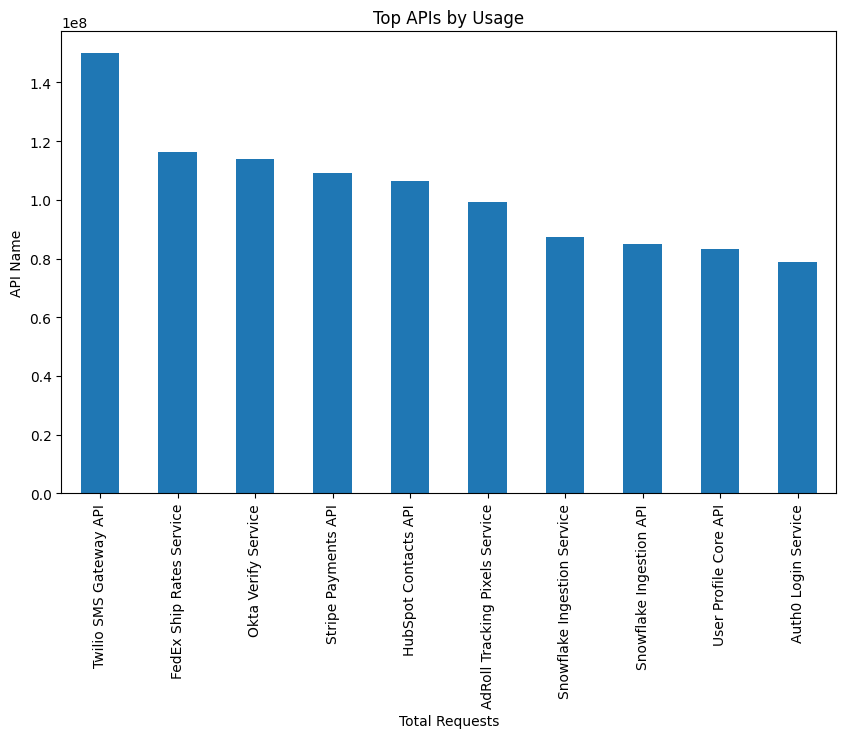

In [32]:
top_apis.plot(kind='bar',figsize=(10,6))
plt.title("Top APIs by Usage")
plt.xlabel("Total Requests")
plt.ylabel("API Name")

plt.show()

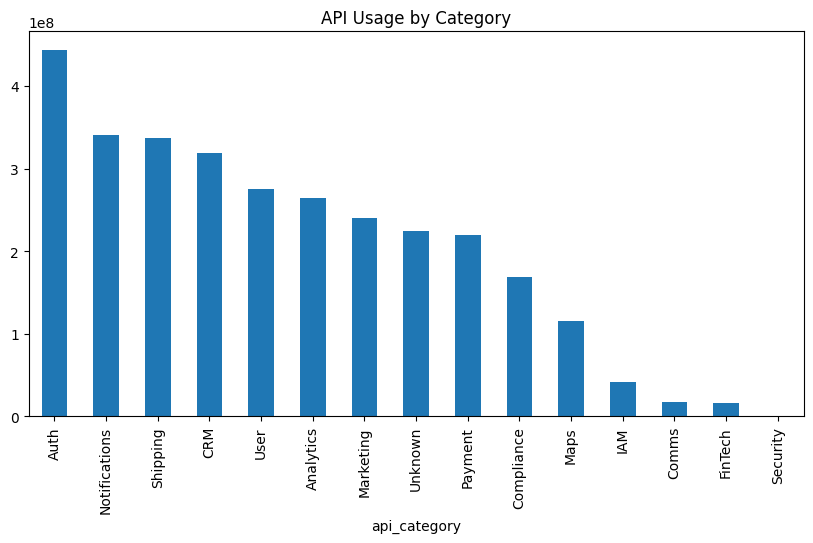

In [34]:
category_usage.plot(kind='bar',figsize=(10,5))
plt.title("API Usage by Category")

plt.show()

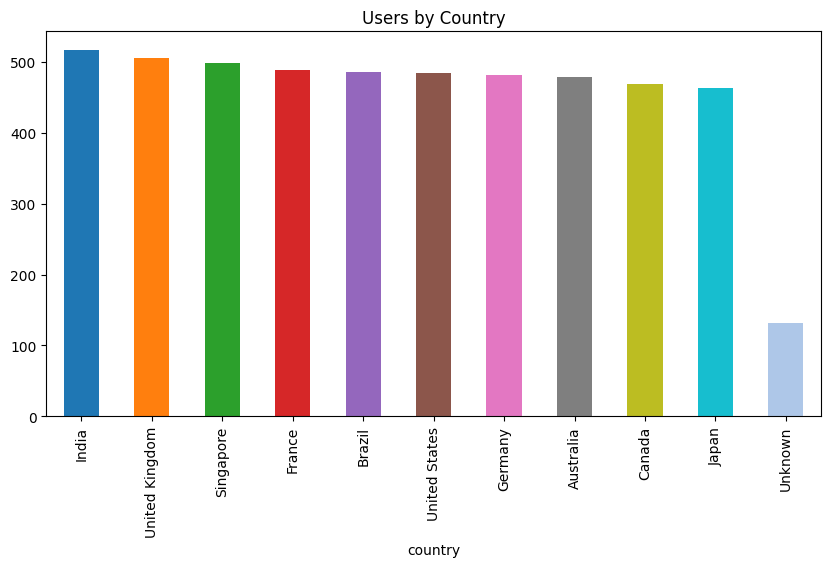

In [40]:
country_users = users['country'].value_counts()

country_users

country_users.plot(kind='bar', figsize=(10,5),color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8'])

plt.title("Users by Country")

plt.show()

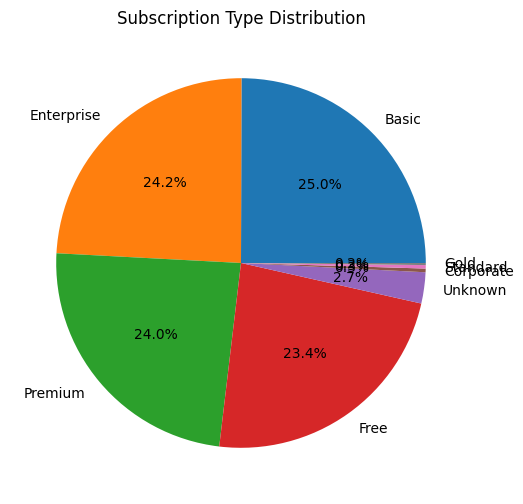

In [45]:
subs=users['subscription_type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(subs,labels=subs.index,autopct='%1.1f%%')

plt.title("Subscription Type Distribution")

plt.show()

In [46]:
api_logs['response_time_ms'].describe()

count     5000.000000
mean      2383.188956
std      11480.664138
min         -1.000000
25%         74.267500
50%        200.385000
75%        346.172500
max      99999.990000
Name: response_time_ms, dtype: float64

In [51]:
api_logs = api_logs[api_logs['response_time_ms'] >= 0]
api_logs = api_logs[api_logs['response_time_ms'] <= 5000]
api_logs['response_time_ms'].describe()

count    4578.000000
mean      199.317169
std       136.556251
min         4.270000
25%        71.995000
50%       186.410000
75%       316.677500
max       589.470000
Name: response_time_ms, dtype: float64

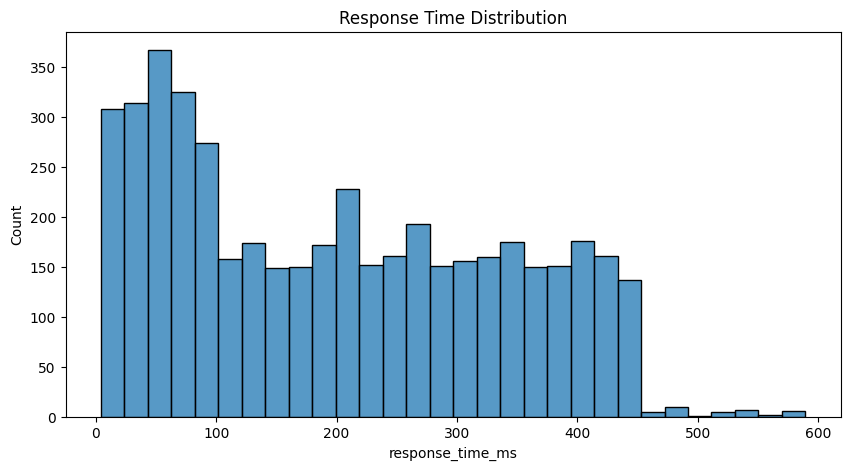

In [54]:
plt.figure(figsize=(10,5))

sns.histplot(api_logs['response_time_ms'], bins=30)

plt.title("Response Time Distribution")

plt.show()

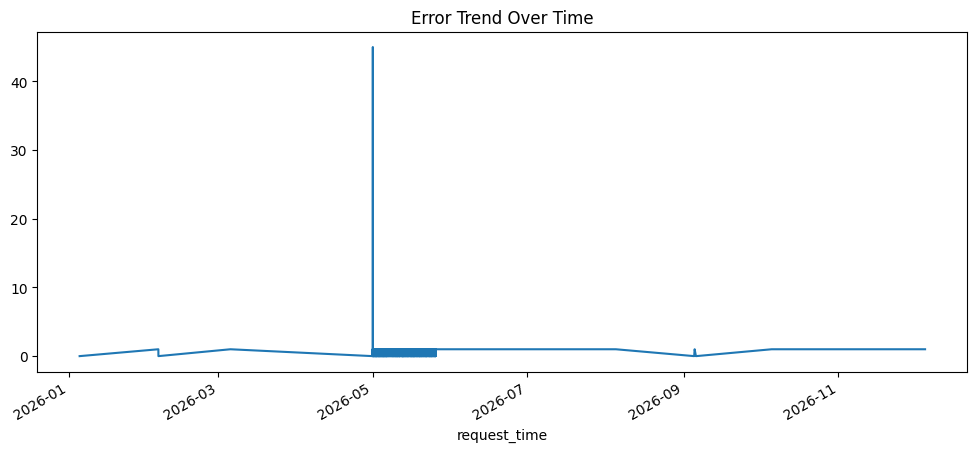

In [56]:
api_logs['is_error'].value_counts()

error_trend = api_logs.groupby('request_time')['is_error'] \
                  .sum()

error_trend.plot(figsize=(12,5))

plt.title("Error Trend Over Time")

plt.show()

In [57]:
corr = api_logs[['response_time_ms',
             'cpu_usage',
             'memory_usage',
             'request_count']].corr()

corr

,response_time_ms,cpu_usage,memory_usage,request_count
response_time_ms,1.000000,0.188843,0.258617,-0.009327
cpu_usage,0.188843,1.000000,0.139337,-0.009195
memory_usage,0.258617,0.139337,1.000000,0.002065
request_count,-0.009327,-0.009195,0.002065,1.000000


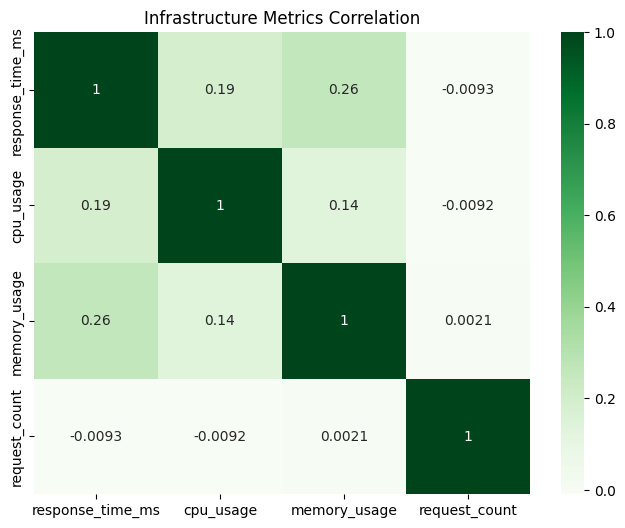

In [58]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='Greens')

plt.title("Infrastructure Metrics Correlation")

plt.show()

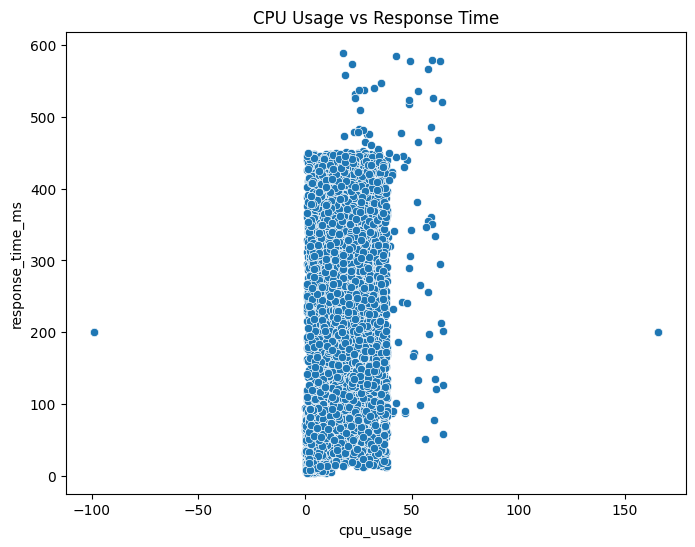

In [59]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=api_logs,
    x='cpu_usage',
    y='response_time_ms'
)

plt.title("CPU Usage vs Response Time")

plt.show()

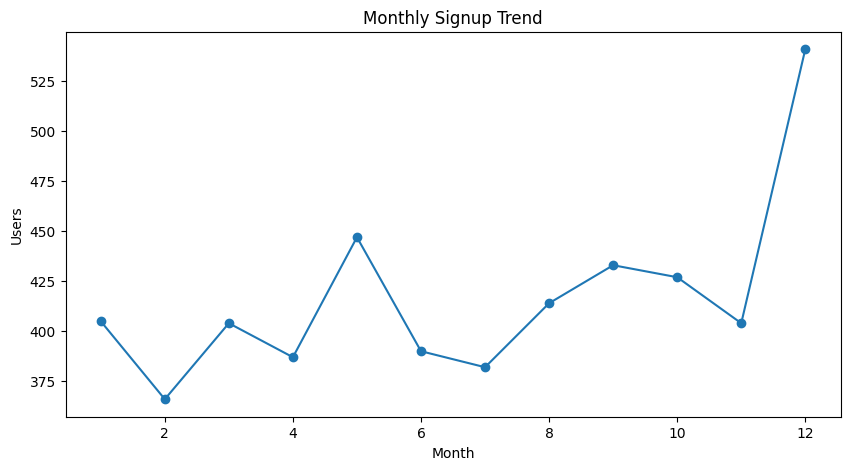

In [62]:
users['signup_date'] = pd.to_datetime(users['signup_date'])

monthly_signup = users.groupby(users['signup_date'].dt.month)['user_id'].count()

monthly_signup

monthly_signup.plot(marker='o', figsize=(10,5))

plt.title("Monthly Signup Trend")

plt.xlabel("Month")
plt.ylabel("Users")

plt.show()

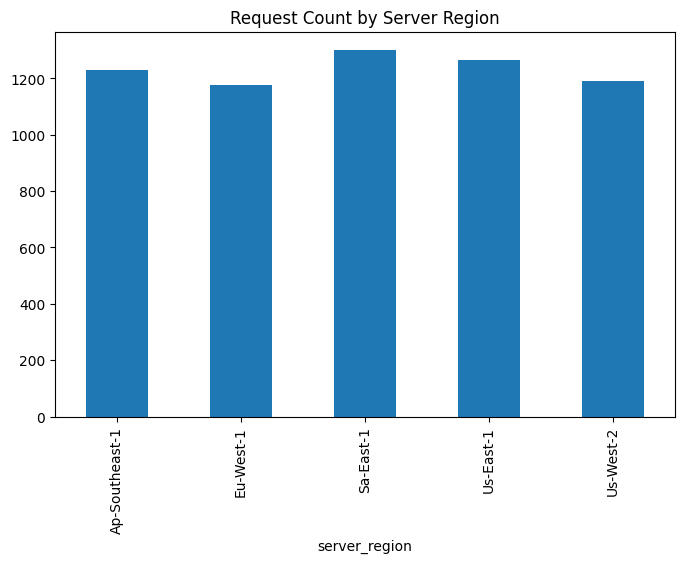

In [64]:
region_requests = api_logs.groupby('server_region')['request_count'].sum()

region_requests

region_requests.plot(kind='bar', figsize=(8,5))

plt.title("Request Count by Server Region")

plt.show()

In [70]:
slow_apis = api_logs.groupby('api_id')['response_time_ms'].mean() \
                .sort_values(ascending=False).head(10)
                
api_errors = df.groupby('api_name')['failed_requests'].sum()

api_total = df.groupby('api_name')['total_requests'].sum()

error_rate = (api_errors/api_total)*100
print('error_rate:-',error_rate)

error_rate:- api_name
AUTH0 LOGIN SERVICE               1.633821
AdRoll Tracking Pixels API        2.292801
AdRoll Tracking Pixels Service    1.183233
Analytics Engine #14              3.157714
Analytics Engine #65              1.503636
                                    ...   
sendgrid mailer service           3.723993
user engine #26                   2.541110
user engine #54                   2.315877
user engine #78                   4.226072
user profile core api             4.154634
Length: 137, dtype: float64


<Axes: xlabel='response_time_ms'>

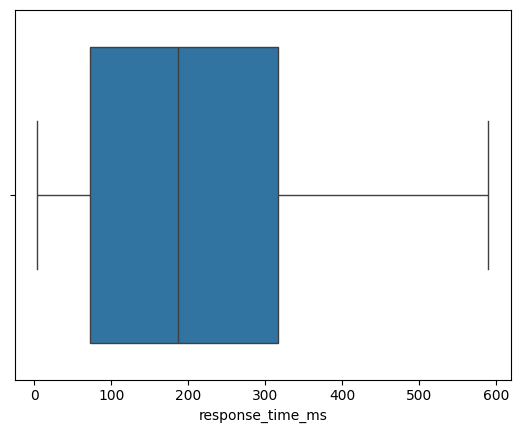

In [71]:
sns.boxplot(x=api_logs['response_time_ms'])

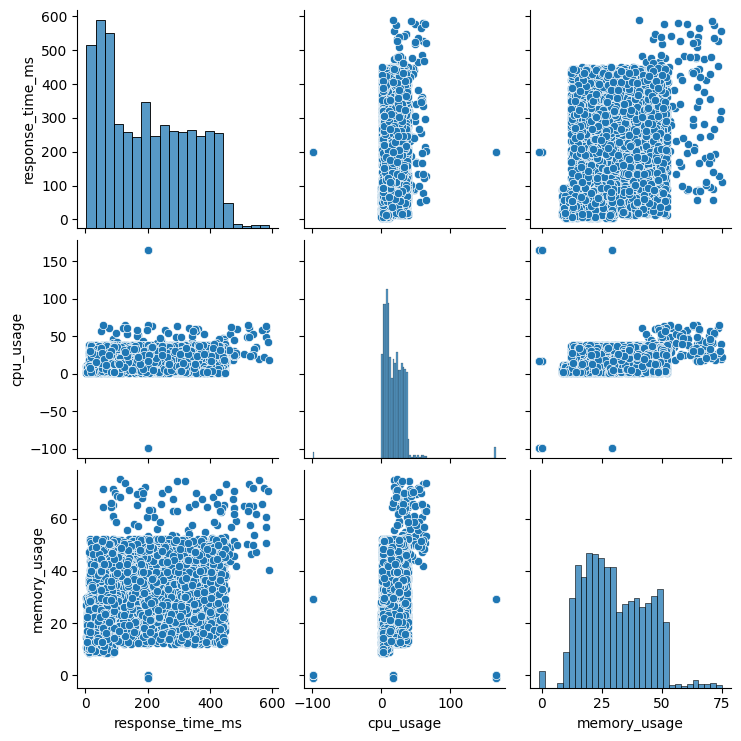

In [72]:
sns.pairplot(api_logs[['response_time_ms','cpu_usage','memory_usage']])